# Assignment - Anomaly Detection

## Phase 1: EDA & Hiểu Data

In [18]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats
from statsmodels.graphics.tsaplots import plot_acf

# 1. Load Data
file_path = 'realKnownCause/ambient_temperature_system_failure.csv'

df = pd.read_csv(file_path)
df['timestamp'] = pd.to_datetime(df['timestamp'])

print("Data Overview")
print(df.head())


Data Overview
            timestamp      value
0 2013-07-04 00:00:00  69.880835
1 2013-07-04 01:00:00  71.220227
2 2013-07-04 02:00:00  70.877805
3 2013-07-04 03:00:00  68.959400
4 2013-07-04 04:00:00  69.283551


In [19]:
# 2. Tính basic stats: mean, std, skewness (dùng scipy.stats.skew), min, max
mean_val = df['value'].mean()
std_val = df['value'].std()
skew_val = stats.skew(df['value'])
min_val = df['value'].min()
max_val = df['value'].max()

print("\nBasic Statistics")
print(f"Mean: {mean_val:.3f}")
print(f"Std: {std_val:.3f}")
print(f"Skewness: {skew_val:.3f}")
print(f"Min: {min_val:.3f}")
print(f"Max: {max_val:.3f}")


Basic Statistics
Mean: 71.242
Std: 4.248
Skewness: -0.393
Min: 57.458
Max: 86.223


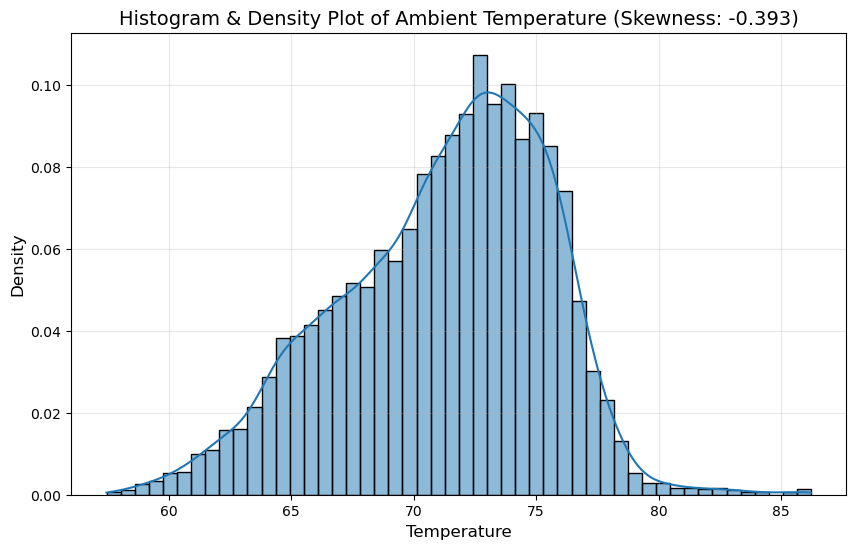

In [20]:
# 3. Plot histogram + density → data có Gaussian không? Skewed không? (dùng kiến thức section 1)
plt.figure(figsize=(10, 6))
sns.histplot(df['value'], kde=True, bins=50, stat="density")

plt.title(f'Histogram & Density Plot of Ambient Temperature (Skewness: {stats.skew(df['value']):.3f})', fontsize=14)
plt.xlabel("Temperature", fontsize=12)
plt.ylabel("Density", fontsize=12)
plt.grid(True, alpha=0.3)
plt.show()


Data gần tuân theo dạng Gaussian, nhưng không hoàn hảo 100% 

Data bị left Skewed nhẹ và có skewed value = -0.393 (nằm trong khoảng từ -0.5 đến 0.5)


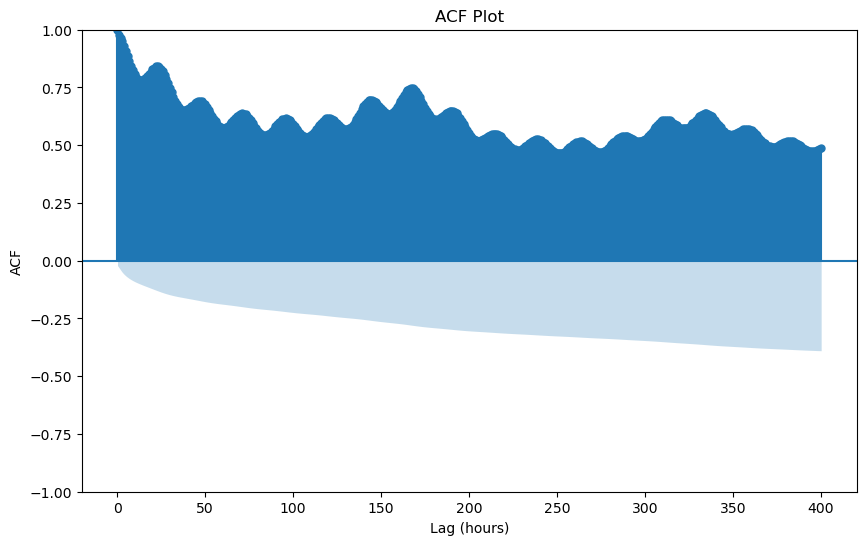

In [21]:
# 4. Plot ACF (statsmodels.graphics.tsaplots.plot_acf) → có seasonal không? Period bao nhiêu?
fig, ax = plt.subplots(figsize=(10, 6))

plot_acf(df['value'], lags=400, ax=ax)

plt.title('ACF Plot')
plt.xlabel('Lag (hours)')
plt.ylabel('ACF')

plt.show()

Biểu đồ ACF cho thấy data có seasonal do các đỉnh nhọn nhấp nhô có chu kỳ

Sau lag 0, đỉnh nhọn đầu tiên xuất hiện tại khoảng Lag 24-25. Các đỉnh tiếp theo xuất hiện tại khoảng Lag 48, 72, 96 nên Period của tập data là khoảng 24 giờ

Dữ liệu có tính Seasonal: Đồ thị ACF cho thấp các đỉnh nhọn tuần hoàn theo chu kỳ của dữ liệu là 24h 

Dùng STL Decomposition + 3σ là phù hợp cho bộ dữ liệu này

## Phase 2: Implement 2 Detectors
### Detector 1 - Statistical

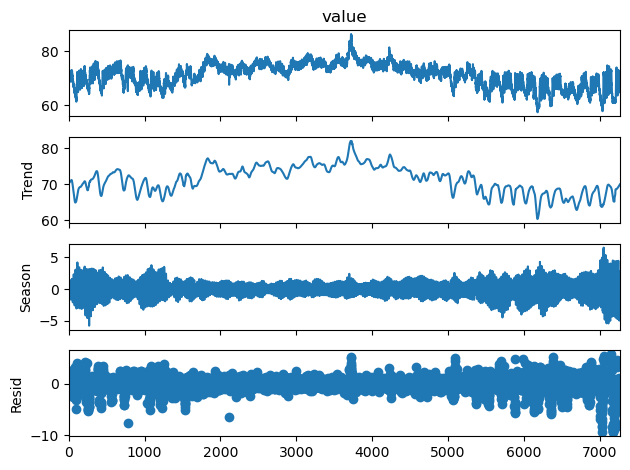

Tổng data: 7267
Số anomaly tìm thấy: 182


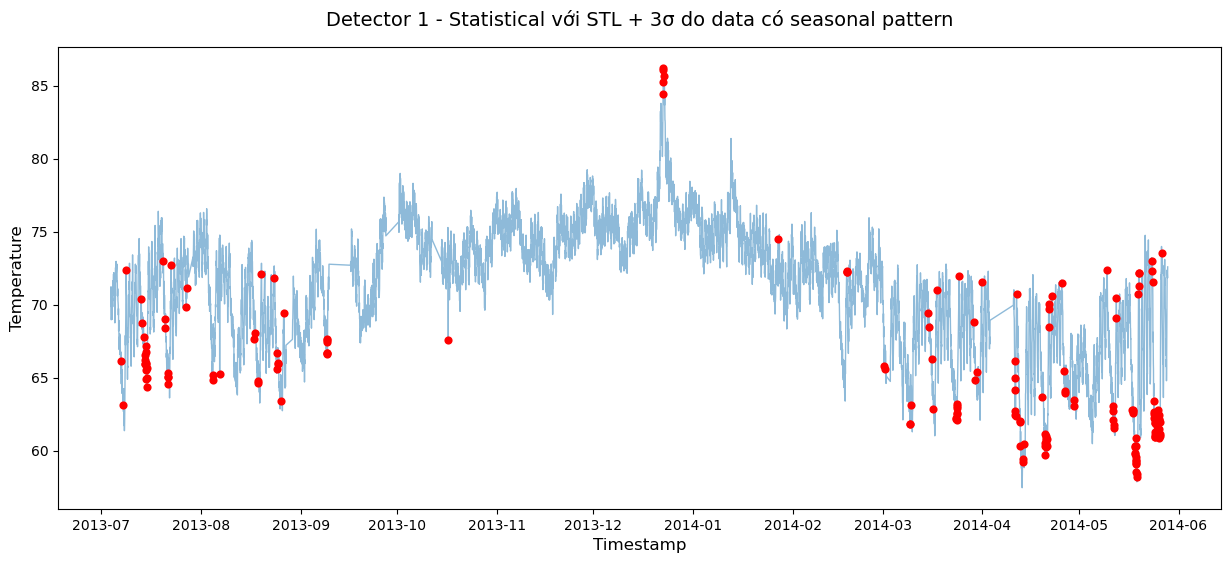

In [30]:
from statsmodels.tsa.seasonal import STL

# STL Decomposition
stl = STL(df['value'], period=24, robust=True)
res = stl.fit()

# Lưu Residual vào DataFrame
df['residual'] = res.resid

# Đồ thị các components
res.plot()
plt.show()

residual = df['residual'].values
resid_mean = np.mean(residual)
resid_std = np.std(residual)

threshold = 3.0

# Tìm anomaly
df['is_anomaly_stl'] = np.abs(residual - resid_mean) > threshold * resid_std

# Tính toán upperlower bound
df['lower_bound'] = resid_mean - threshold * resid_std
df['upper_bound'] = resid_mean + threshold * resid_std

# Số anomaly tìm thấy
total_anomalies = df['is_anomaly_stl'].sum()
print(f"Tổng data: {len(df)}")
print(f"Số anomaly tìm thấy: {total_anomalies}")

# Visualize với anomaly
plt.figure(figsize=(15, 6))

plt.plot(df['timestamp'], df['value'], alpha=0.5, linewidth=1, label='Nhiệt độ thực tế')

# Lọc các anomaly trên biểu đồ
anomalies_df = df[df['is_anomaly_stl'] == True]
plt.scatter(anomalies_df['timestamp'], anomalies_df['value'], 
            color='red', marker='o', s=15, linewidths=2, label='Anomaly phát hiện', zorder=5)

# Label các cột và tittle
plt.title("Detector 1 - Statistical với STL + 3σ do data có seasonal pattern", fontsize=14, pad=15)
plt.xlabel("Timestamp", fontsize=12)
plt.ylabel("Temperature", fontsize=12)
plt.show()


### Detector 2 - ML: Isolation Forest

In [36]:
from sklearn.ensemble import IsolationForest
from sklearn.metrics import precision_score, recall_score, f1_score

#  Biến 1 time series thành feature table cho Isolation Forest
s = pd.Series(df['value'])

window_day = 24 

df_features = pd.DataFrame({
    'timestamp': df['timestamp'],
    'value': s,
    'is_anomaly_stl': df['is_anomaly_stl'],
    'rolling_mean_day': s.rolling(window_day).mean(), 
    'rolling_std_day': s.rolling(window_day).std(), 
    'rate_of_change': s.diff(),
    'rate_of_change_6h': s.diff(6), 
    'lag_1': s.shift(1),
    'lag_24': s.shift(window_day), 
})

# Loại row có NaN do shift ở đầu 
df_features = df_features.dropna().reset_index(drop=True)

X = df_features[['value', 'rolling_mean_day', 'rolling_std_day', 
                 'rate_of_change', 'rate_of_change_6h', 'lag_1', 'lag_24']]


# Train Isolation Forest + Tune contamination parameter: thử 0.01, 0.02, 0.05 → ghi lại precision/recall mỗi giá trị
y_true = df['is_anomaly_stl'].iloc[24:].astype(int).values

contamination_list = [0.01, 0.02, 0.05]
results_summary = []


for contam in contamination_list:
    clf = IsolationForest(
        n_estimators=200,  
        contamination=contam, 
        max_features=1.0, 
        random_state=42,
        n_jobs=-1
    )
    clf.fit(X)
    
    # Dự đoán labels (-1: Anomaly, 1: Normal)
    preds = clf.predict(X)
    
    # Chuyển về dạng 0-1 để khớp với df['is_anomaly_stl']
    y_pred = np.where(preds == -1, 1, 0)
    
    # Lưu lại is_anomaly_iforest cho mỗi contamination
    df_features[f'is_anomaly_iforest_{contam}'] = y_pred
    
    # Tính toán Precision và Recall và f1
    precision = precision_score(y_true, y_pred, zero_division=0)
    recall = recall_score(y_true, y_pred, zero_division=0)
    f1 = f1_score(y_true, y_pred, zero_division=0)
    
    # Lưu kết quả
    results_summary.append({
        'Contamination': contam,
        'Precision': round(precision, 4),
        'Recall': round(recall, 4),
        'F1-Score': round(f1, 4),
        'Detected Anomalies': np.sum(y_pred)
    })
    
    print(f"\nContamination = {contam}")
    print(f"- Số anomaly phát hiện: {np.sum(y_pred)}")
    print(f"- Precision: {precision:.4f}")
    print(f"- Recall:    {recall:.4f}")
    print(f"- F1-Score:  {f1:.4f}")


Contamination = 0.01
- Số anomaly phát hiện: 73
- Precision: 0.1370
- Recall:    0.0549
- F1-Score:  0.0784

Contamination = 0.02
- Số anomaly phát hiện: 145
- Precision: 0.1241
- Recall:    0.0989
- F1-Score:  0.1101

Contamination = 0.05
- Số anomaly phát hiện: 363
- Precision: 0.1956
- Recall:    0.3901
- F1-Score:  0.2606


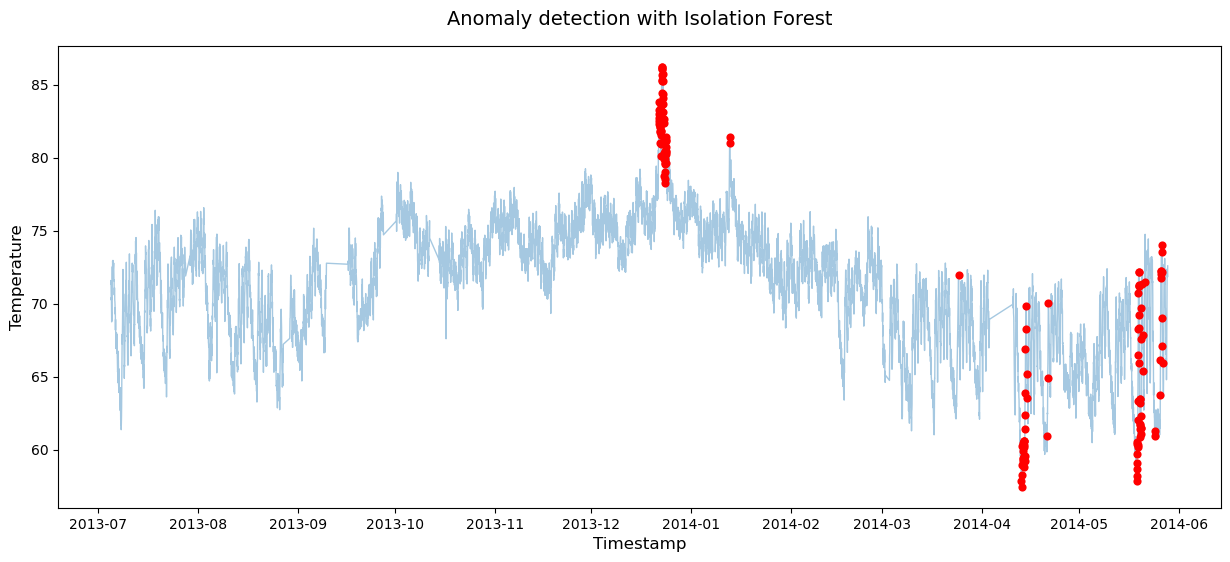

In [29]:
# Plot kết quả anomaly detection detector 2
plot_contam = 0.02

clf_plot = IsolationForest(
    n_estimators=200,  
    contamination=plot_contam, 
    max_features=1.0, 
    random_state=42,
    n_jobs=-1
)
clf_plot.fit(X)

preds_plot = clf_plot.predict(X)
df_features['is_anomaly_iforest'] = np.where(preds_plot == -1, 1, 0)

plt.figure(figsize=(15, 6))


plt.plot(df_features['timestamp'], df_features['value'], 
         color='tab:blue', alpha=0.4, linewidth=1, label='Nhiệt độ thực tế')

# Lọc ra các nhãn anomaly
anomalies_iforest = df_features[df_features['is_anomaly_iforest'] == 1]

# Tìm anomaly trên biểu đồ
plt.scatter(anomalies_iforest['timestamp'], anomalies_iforest['value'], 
            color='red', marker='o', s=15, linewidths=2, label='Anomaly (Isolation Forest)', zorder=5)


plt.title(f"Anomaly detection with Isolation Forest", fontsize=14, pad=15)
plt.xlabel("Timestamp", fontsize=12)
plt.ylabel("Temperature", fontsize=12)

plt.show()

### Tính precision, recall, F1 dùng ground truth label từ NAB

In [25]:
import numpy as np
import pandas as pd
from sklearn.metrics import precision_score, recall_score, f1_score


# 2 mốc thời gian lỗi thật
nab_anomalies = ['2013-12-22 20:00:00', '2014-04-13 09:00:00']
nab_timestamps = pd.to_datetime(nab_anomalies)

# Labels cho các thời điểm lỗi thật
df['ground_truth'] = df['timestamp'].isin(nab_timestamps).astype(int)

# Labels vào trong bảng features
df_features['ground_truth'] = df_features['timestamp'].isin(nab_timestamps).astype(int)

# Lấy mảng giá trị labels lỗi thực để tính
y_true = df_features['ground_truth'].values

print(f"Số labels NAB đã mark: {df_features['ground_truth'].sum()}")


# Tính precision, recall, F1 cho detector 1
# Lấy dự đoán lỗi của STL trùng khớp với các mốc thời gian của df_features
y_pred_stl = df_features['timestamp'].isin(df[df['is_anomaly_stl'] == True]['timestamp']).astype(int).values

p1 = precision_score(y_true, y_pred_stl, zero_division=0)
r1 = recall_score(y_true, y_pred_stl, zero_division=0)
f1_d1 = f1_score(y_true, y_pred_stl, zero_division=0)

# Tính precision, recall, F1 cho detector 2
iforest_metrics = []

for contam in [0.01, 0.02, 0.05]:
    col_name = f'is_anomaly_iforest_{contam}'
    y_pred_if = df_features[col_name].values
    
    p_if = precision_score(y_true, y_pred_if, zero_division=0)
    r_if = recall_score(y_true, y_pred_if, zero_division=0)
    f1_if = f1_score(y_true, y_pred_if, zero_division=0)
    
    iforest_metrics.append({
        'Detector': f'Isolation Forest (contam={contam})',
        'Precision': round(p_if, 4),
        'Recall': round(r_if, 4),
        'F1-Score': round(f1_if, 4),
        'Total Detected': np.sum(y_pred_if)
    })

# Bảng so sánh các metric đã tính
summary_list = [{
    'Detector': 'Detector 1 (STL + 3σ)',
    'Precision': round(p1, 4),
    'Recall': round(r1, 4),
    'F1-Score': round(f1_d1, 4),
    'Total Detected': np.sum(y_pred_stl)
}] + iforest_metrics

df_metrics_final = pd.DataFrame(summary_list)


print(df_metrics_final.to_string(index=False))

Số labels NAB đã mark: 2
                      Detector  Precision  Recall  F1-Score  Total Detected
         Detector 1 (STL + 3σ)     0.0055     0.5    0.0109             182
Isolation Forest (contam=0.01)     0.0137     0.5    0.0267              73
Isolation Forest (contam=0.02)     0.0138     1.0    0.0272             145
Isolation Forest (contam=0.05)     0.0055     1.0    0.0110             363


### Plot: original series + anomalies highlighted cho cả 2 detector (2 subplot, giống hình section 6)

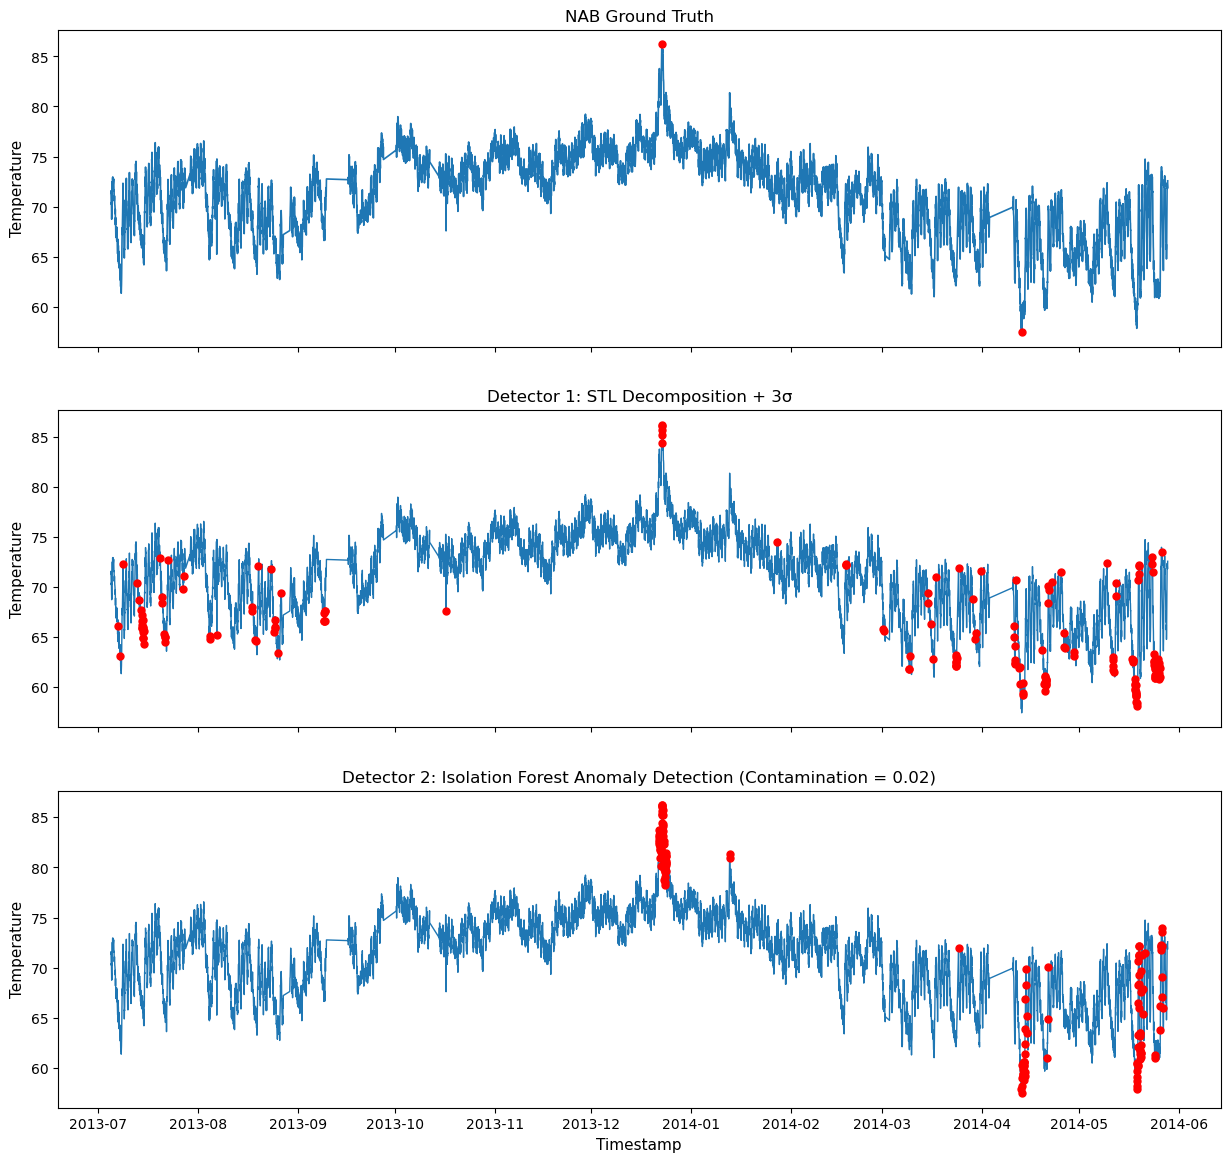

In [34]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

# Chuẩn hóa cột timestampt để plot
df_features['timestamp'] = pd.to_datetime(df_features['timestamp'])



# Tạo 3 subplots xếp chồng lên nhau, chung trục X (sharex=True)
fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(15, 14), sharex=True)


# ground truth labels
ax1.plot(df_features['timestamp'], df_features['value'], linewidth=1.2, label='Nhiệt độ thực tế')

# Lọc ra 2 điểm anomaly từ NAB
nab_real_anomalies = df_features[df_features['ground_truth'] == 1]

# Chấm các anomaly thật sự từ NAB lên biểu đồ
ax1.scatter(nab_real_anomalies['timestamp'], nab_real_anomalies['value'], 
            color='red', marker='o', s=25, label='Sự cố thật (NAB Ground Truth)', zorder=5)

# Set labels
ax1.set_title("NAB Ground Truth", fontsize=12)
ax1.set_ylabel("Temperature", fontsize=11)


# DETECTOR 1 - STL + 3σ
# Dữ liệu thực tế 
ax2.plot(df_features['timestamp'], df_features['value'], linewidth=1, label='Nhiệt độ thực tế')

# Anomaly phát hiện bởi STL
anomalies_stl = df_features[df_features['is_anomaly_stl'] == True]

# Chấm các anomaly bởi stl lên biểu đồ
ax2.scatter(anomalies_stl['timestamp'], anomalies_stl['value'], 
            color='red', marker='o', s=25, label='Điểm bất thường (STL)', zorder=5)

# Set labels
ax2.set_title("Detector 1: STL Decomposition + 3σ", fontsize=12)
ax2.set_ylabel("Temperature", fontsize=11)



# DETECTOR 2 - IF
# Dữ liệu thực tế 
ax3.plot(df_features['timestamp'], df_features['value'], linewidth=1, label='Nhiệt độ thực tế')

# Anomaly phát hiện bởi Isolation Forest
anomalies_iforest = df_features[df_features['is_anomaly_iforest_0.02'] == 1]

# Chấm các anomaly bởi stl lên biểu đồ
ax3.scatter(anomalies_iforest['timestamp'], anomalies_iforest['value'], 
            color='red', marker='o', s=25, label='Điểm bất thường (IF)', zorder=5)


ax3.set_title("Detector 2: Isolation Forest Anomaly Detection (Contamination = 0.02)", fontsize=12)
ax3.set_xlabel("Timestamp", fontsize=11)
ax3.set_ylabel("Temperature", fontsize=11)

plt.show()

## Phase 3: So Sánh & Reflection
### Tạo bảng so sánh 2 detector

| Metric | Detector 1 (STL + 3σ) | Detector 2 (IF - 0.02) |
| :--- | :---: | :---: |
| **Precision** | 0.0055 | 0.0138 |
| **Recall** | 0.5 | 1.0 |
| **F1-Score** | 0.0109 | 0.0272 |
| **False Alarms** | 181 | 143 |

</br>

> Chọn IF với Contamination = 0.02 vì với contamination=0.01, recall = 0.5 tỉ lệ bắt được anomaly chỉ 50%. Với contanmination= 0.03 thì mặc dù recall = 1 nhưng số lượng bắt được lại quá cao. Do đó chọn contamination = 0.02 thì vừa đạt được recall = 1 nhưng số lượng detect không quá cao như 0.03

### Thử tune threshold / window size / contamination → ghi lại kết quả (ít nhất 3 lần tune)

Kết quả được lấy từ Phase 2 detector 2 sau khi tune contamination 3 lần với 0.01 - 0.02 và 0.03

Contamination = 0.01
- Số anomaly phát hiện: 73
- Precision: 0.1370
- Recall:    0.0549
- F1-Score:  0.0784

Contamination = 0.02
- Số anomaly phát hiện: 145
- Precision: 0.1241
- Recall:    0.0989
- F1-Score:  0.1101

Contamination = 0.05
- Số anomaly phát hiện: 363
- Precision: 0.1956
- Recall:    0.3901
- F1-Score:  0.2606

### Model artifacts: file .pkl hoặc .joblib của Isolation Forest đã train (nhỏ, < 1MB)

In [37]:
import joblib

# Chọn contamination = 0.02 là ổn nhất do recall=1 và số lượng detect không bị nhiều như contamination = 0.03
best_contam = 0.02

# Train lại model 
best_clf = IsolationForest(
    n_estimators=200,  
    contamination=best_contam, 
    max_features=1.0, 
    random_state=42,
    n_jobs=-1
)
best_clf.fit(X)

# Lưu mô hình thành file .joblib
joblib_filename = 'isolation_forest_model.joblib'
joblib.dump(best_clf, joblib_filename)
print(f"Đã lưu thành công")



Đã lưu thành công
